In [ ]:
from __future__ import annotations

import hashlib
import json
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import requests

!pip install -q astroquery gala galstreams

from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u
import galstreams





SIM = "TNG50-1"
SNAP = 99  # z = 0
BASE_URL = f"http://www.tng-project.org/api/{SIM}/snapshots/{SNAP}/"
API_KEY = "fb0a2a4f6b517ee45f49a4321f51b4c9 "

# TNG / Planck15 cosmology
H_HUBBLE = 0.6774
A_SCALE = 1.0  # snapshot 99 is z = 0

# Default selection cuts
# MW-analog hosts: select on the central subhalo's total bound mass, which
# corresponds to roughly the same number for the FoF group's DM mass. Range
# straddles canonical MW estimates (1.0-1.5e12) and slightly heavier analogs.
MW_HALO_MASS_MSUN = (1.0e12, 2.0e12)
PERTURBER_MASS_MSUN = (1.0e6, 1.0e9)
PERTURBER_R_RANGE_KPC = (10.0, 100.0)



# Stream-perturbation defaults
DEFAULT_STREAM_AGE_GYR = 3
DEFAULT_V_REL_KMS = 200.0
DEFAULT_BMAX_OVER_RS = 5.0
KPC_PER_KMS_GYR = 1.02271  # 1 km/s * 1 Gyr in kpc

# On-disk layout
DATA_DIR = Path.cwd() / "illustris_data"
API_CACHE_DIR = DATA_DIR / "api_cache"
HALO_CACHE_DIR = DATA_DIR / "halos"
DOWNLOADS_DIR = DATA_DIR / "downloads"
MW_LIST_FILE = DATA_DIR / "mw_halos.json"


# -----------------------------------------------------------------------------
# Disk-cached API client
# -----------------------------------------------------------------------------


def _cache_key(url: str, params: dict | None) -> str:
    blob = url
    if params:
        blob += "?" + json.dumps(params, sort_keys=True)
    return hashlib.sha1(blob.encode()).hexdigest()[:20]


def _read_json_cache(url: str, params: dict | None):
    f = API_CACHE_DIR / f"{_cache_key(url, params)}.json"
    if f.exists():
        with open(f) as fp:
            return json.load(fp)
    return None


def _write_json_cache(url: str, params: dict | None, data) -> None:
    API_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    with open(API_CACHE_DIR / f"{_cache_key(url, params)}.json", "w") as fp:
        json.dump(data, fp)


def _http_get(url: str, params: dict | None = None, retries: int = 8):
    headers = {"api-key": API_KEY}
    for n in range(retries):
        try:
            r = requests.get(url, params=params, headers=headers, timeout=60)
            r.raise_for_status()
            return r
        except (requests.HTTPError, requests.ConnectionError, requests.Timeout):
            if n == retries - 1:
                raise
            time.sleep(min(2**n, 30))


def get(url: str, params: dict | None = None):
    """
    GET an Illustris API URL with disk caching.

    JSON responses are cached forever (keyed by URL+params hash). Binary
    downloads are saved to illustris_data/downloads/ and the path is returned.
    """
    cached = _read_json_cache(url, params)
    if cached is not None:
        return cached

    r = _http_get(url, params)
    ctype = r.headers.get("content-type", "")
    if ctype.startswith("application/json"):
        data = r.json()
        _write_json_cache(url, params, data)
        return data

    if "content-disposition" in r.headers:
        fname = r.headers["content-disposition"].split("filename=")[1].strip('"_; ')
        DOWNLOADS_DIR.mkdir(parents=True, exist_ok=True)
        out = DOWNLOADS_DIR / fname
        with open(out, "wb") as fp:
            fp.write(r.content)
        return str(out)

    return r.content


# -----------------------------------------------------------------------------
# Unit conversions (TNG code units -> physical)
# -----------------------------------------------------------------------------
# TNG masses are in 10^10 Msun/h; lengths are comoving kpc/h.


def code_mass_to_msun(m_code):
    return np.asarray(m_code) * 1e10 / H_HUBBLE


def msun_to_code_mass(m_msun):
    return np.asarray(m_msun) * H_HUBBLE / 1e10


def code_length_to_kpc(x_code, a: float = A_SCALE):
    return np.asarray(x_code) * a / H_HUBBLE


# -----------------------------------------------------------------------------
# MW-like host halo selection
# -----------------------------------------------------------------------------


def find_mw_halos(
    mass_range_msun=MW_HALO_MASS_MSUN,
    force_refresh: bool = False,
    n_workers: int = 8,
    verbose: bool = True,
) -> list[int]:
    """
    Find MW-analog FoF groups by selecting central (primary) subhalos whose
    total bound mass lies in mass_range_msun, then reading their FoF group
    index (grnr).

    This uses the /subhalos/?primary_flag=1 list endpoint with a server-side
    mass filter, which is far faster than scanning halo indices one-by-one.

    Returns a sorted list of FoF group indices, cached to mw_halos.json.
    """
    if MW_LIST_FILE.exists() and not force_refresh:
        with open(MW_LIST_FILE) as f:
            return json.load(f)

    m_lo_code = float(msun_to_code_mass(mass_range_msun[0]))
    m_hi_code = float(msun_to_code_mass(mass_range_msun[1]))
    page = get(
        f"{BASE_URL}subhalos/",
        {
            "primary_flag": 1,
            "mass__gt": m_lo_code,
            "mass__lt": m_hi_code,
            "limit": 5000,
        },
    )
    centrals = page["results"]
    if verbose:
        print(
            f"found {len(centrals)} primary subhalos with M in "
            f"[{mass_range_msun[0]:.1e}, {mass_range_msun[1]:.1e}] Msun"
        )

    # Each central's detail gives us the parent FoF group index (grnr).
    urls = [c["url"] for c in centrals]
    with ThreadPoolExecutor(max_workers=n_workers) as ex:
        details = list(ex.map(get, urls))

    halo_indices = sorted({d["grnr"] for d in details})

    DATA_DIR.mkdir(parents=True, exist_ok=True)
    with open(MW_LIST_FILE, "w") as f:
        json.dump(halo_indices, f)
    if verbose:
        print(f"wrote {len(halo_indices)} MW-analog halo indices to {MW_LIST_FILE}")
    return halo_indices


# -----------------------------------------------------------------------------
# Subhalo fetching for a given host
# -----------------------------------------------------------------------------


def _list_subhalos_in_group(halo_idx: int, mass_range_msun=PERTURBER_MASS_MSUN):
    """
    Return subhalos in FoF group with the fields needed for analysis.
    If the API supports 'fields', this avoids one request per subhalo.
    """
    mass_lo_code = msun_to_code_mass(mass_range_msun[0])
    mass_hi_code = msun_to_code_mass(mass_range_msun[1])

    url = f"{BASE_URL}subhalos/"
    out = []
    offset = 0
    page_size = 5000

    while True:
        params = {
            "grnr": halo_idx,
            "mass__gt": float(mass_lo_code),
            "mass__lt": float(mass_hi_code),
            "limit": page_size,
            "offset": offset,

            # Request only the fields we actually need
            "fields": "id,mass,pos_x,pos_y,pos_z",
        }

        page = get(url, params)
        results = page.get("results", [])
        out.extend(results)

        if len(results) < page_size:
            break

        offset += page_size

    return out


def fetch_subhalos(
    halo_idx: int,
    mass_range_msun=PERTURBER_MASS_MSUN,
    n_workers: int = 256,
    verbose: bool = True,
) -> dict:
    """
    Fetch all subhalos in mass_range_msun for FoF group halo_idx. Caches the
    result to illustris_data/halos/halo_<idx>.npz so subsequent calls are
    instant.

    Returns a dict with arrays:
        id          : (N,) int64
        mass_msun   : (N,) float
        pos_kpc     : (N, 3) float, simulation-box coordinates [physical kpc]
        R_kpc       : (N,) float, distance to host center [physical kpc]
        halo_pos_kpc: (3,) float, host center position
    """
    cache = HALO_CACHE_DIR / f"halo_{halo_idx}.npz"
    if cache.exists():
        d = np.load(cache)
        return {k: d[k] for k in d.files}

    halo = get(f"{BASE_URL}halos/{halo_idx}/")
    info = get(halo["meta"]["info"])
    halo_pos = code_length_to_kpc(np.array(info["GroupPos"], dtype=float))

    listing = _list_subhalos_in_group(halo_idx, mass_range_msun)
    urls = [s["url"] for s in listing]

    if verbose:
        print(f"halo {halo_idx}: fetching {len(urls)} subhalos...")

    # Concurrent per-subhalo fetches. `get` is cached, so re-fetches are free.
    results = [None] * len(urls)
    with ThreadPoolExecutor(max_workers=n_workers) as ex:
        future_to_i = {ex.submit(get, u): i for i, u in enumerate(urls)}
        done = 0
        for fut in as_completed(future_to_i):
            i = future_to_i[fut]
            results[i] = fut.result()
            done += 1
            if verbose and done % (len(urls)//3) == 0:
                print(f"  halo {halo_idx}: {done}/{len(urls)} fetched")

    ids = np.array([d["id"] for d in results], dtype=np.int64)
    mass_code = np.array([d["mass"] for d in results], dtype=float)
    pos_code = np.array(
        [[d["pos_x"], d["pos_y"], d["pos_z"]] for d in results], dtype=float
    )
    mass_msun = code_mass_to_msun(mass_code)
    pos_kpc = code_length_to_kpc(pos_code)
    R_kpc = np.linalg.norm(pos_kpc - halo_pos, axis=1)

    HALO_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    np.savez(
        cache,
        id=ids,
        mass_msun=mass_msun,
        pos_kpc=pos_kpc,
        R_kpc=R_kpc,
        halo_pos_kpc=halo_pos,
    )
    return {
        "id": ids,
        "mass_msun": mass_msun,
        "pos_kpc": pos_kpc,
        "R_kpc": R_kpc,
        "halo_pos_kpc": halo_pos,
    }

In [ ]:
mw_halos = find_mw_halos()

halo = mw_halos[0]

data = fetch_subhalos(halo)


print("Halo:", halo)
print("Number of subhalos:", len(data["id"]))
print("Mass range:")
print(data["mass_msun"].min(), data["mass_msun"].max())

Halo: 77
Number of subhalos: 1275
Mass range:
9078830.82373782 992736935.3410097


In [ ]:
# Finding all Milky Way-like halos


mw_halos = find_mw_halos(
    mass_range_msun=(1e12, 2e12),
    force_refresh=False,
    verbose=True,
)

print(f"\nFound {len(mw_halos)} Milky Way analog halos.\n")
print("First 10 halo IDs:")
print(mw_halos[:10])

# Downloading subhalos for each MW halo

all_halos = {}

for i, halo_idx in enumerate(mw_halos):

    print(f"\nProcessing halo {i+1}/{len(mw_halos)} (FoF group {halo_idx})")

    data = fetch_subhalos(
        halo_idx=halo_idx,
        mass_range_msun=(1e6, 1e9),
        verbose=True,
    )

    all_halos[halo_idx] = data

    cache = HALO_CACHE_DIR / f"halo_{halo_idx}.npz"

    print(f"Number of subhalos : {len(data['id'])}")
    print(f"Mean mass          : {np.mean(data['mass_msun']):.2e} Msun")
    print(f"Median distance    : {np.median(data['R_kpc']):.2f} kpc")

print("\nFinished downloading all MW analog halos.")


Found 103 Milky Way analog halos.

First 10 halo IDs:
[77, 85, 89, 90, 95, 103, 106, 108, 112, 113]

Processing halo 1/103 (FoF group 77)
Number of subhalos : 1275
Mean mass          : 6.35e+07 Msun
Median distance    : 348.94 kpc

Processing halo 2/103 (FoF group 85)
Number of subhalos : 1228
Mean mass          : 6.56e+07 Msun
Median distance    : 333.86 kpc

Processing halo 3/103 (FoF group 89)
Number of subhalos : 1092
Mean mass          : 6.34e+07 Msun
Median distance    : 373.84 kpc

Processing halo 4/103 (FoF group 90)
Number of subhalos : 1005
Mean mass          : 6.85e+07 Msun
Median distance    : 274.35 kpc

Processing halo 5/103 (FoF group 95)
Number of subhalos : 1036
Mean mass          : 6.44e+07 Msun
Median distance    : 236.52 kpc

Processing halo 6/103 (FoF group 103)
Number of subhalos : 839
Mean mass          : 6.16e+07 Msun
Median distance    : 272.86 kpc

Processing halo 7/103 (FoF group 106)
Number of subhalos : 536
Mean mass          : 5.53e+07 Msun
Median distanc

dict_keys(['id', 'mass_msun', 'pos_kpc', 'R_kpc', 'halo_pos_kpc'])
414
ID =  546879 | Mass = 2.83e+08 Msun | R =  62.08 kpc
ID =  546880 | Mass = 9.77e+08 Msun | R = 225.33 kpc
ID =  546881 | Mass = 9.58e+08 Msun | R = 234.61 kpc
ID =  546882 | Mass = 9.41e+08 Msun | R = 270.34 kpc
ID =  546883 | Mass = 8.38e+08 Msun | R = 240.03 kpc
ID =  546884 | Mass = 6.71e+08 Msun | R = 138.00 kpc
ID =  546885 | Mass = 6.61e+08 Msun | R = 278.48 kpc
ID =  546886 | Mass = 6.42e+08 Msun | R = 301.03 kpc
ID =  546887 | Mass = 6.16e+08 Msun | R = 148.98 kpc
ID =  546888 | Mass = 6.05e+08 Msun | R = 287.07 kpc


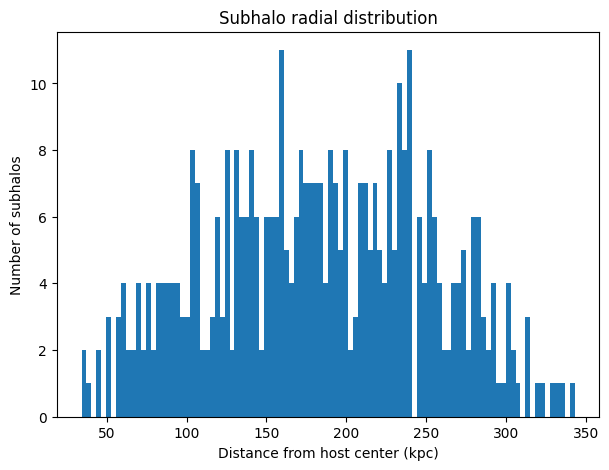

In [ ]:
print(data.keys())
print(len(data["R_kpc"]))

for i in range(10):
    print(
        f"ID = {data['id'][i]:7d} | "
        f"Mass = {data['mass_msun'][i]:.2e} Msun | "
        f"R = {data['R_kpc'][i]:6.2f} kpc"
    )





plt.figure(figsize=(7,5))
plt.hist(data["R_kpc"], bins=100)
plt.xlabel("Distance from host center (kpc)")
plt.ylabel("Number of subhalos")
plt.title("Subhalo radial distribution")
plt.show()

Shell volume = 2.64e+05 kpc^3

Indus-S19
Median      : 0.098
16th pctile : 0.042
84th pctile : 0.285


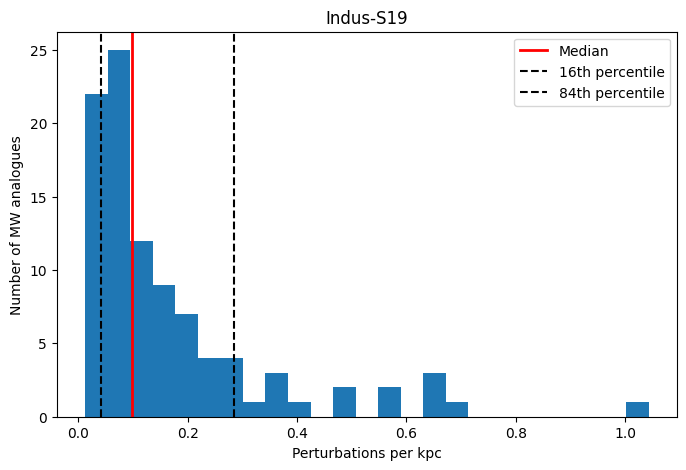


C-12-I24
Median      : 0.098
16th pctile : 0.042
84th pctile : 0.285


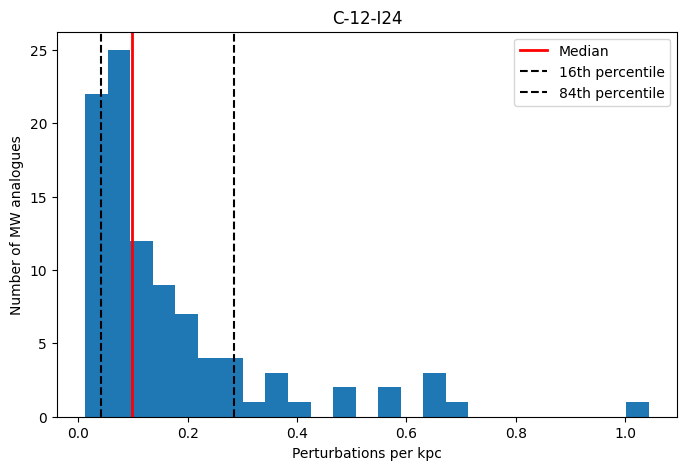


Ylgr-I21
Median      : 0.098
16th pctile : 0.042
84th pctile : 0.285


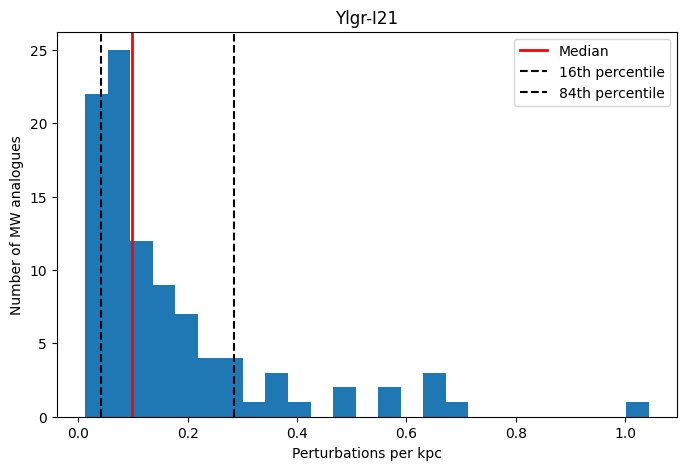


Orphan-K23
Median      : 0.098
16th pctile : 0.042
84th pctile : 0.285


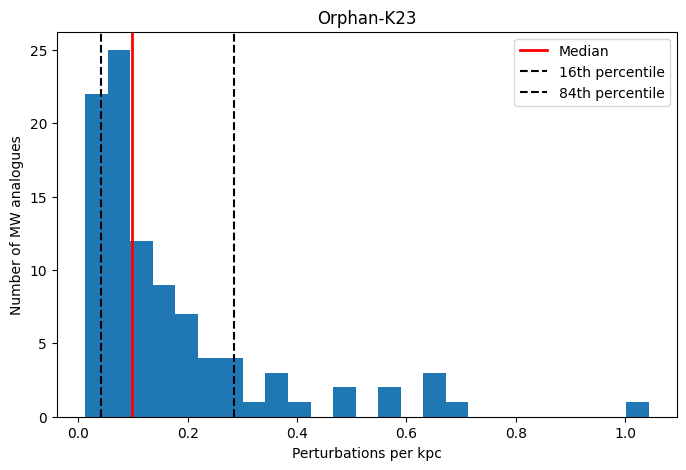


NGC6397-I21
Median      : 0.098
16th pctile : 0.042
84th pctile : 0.285


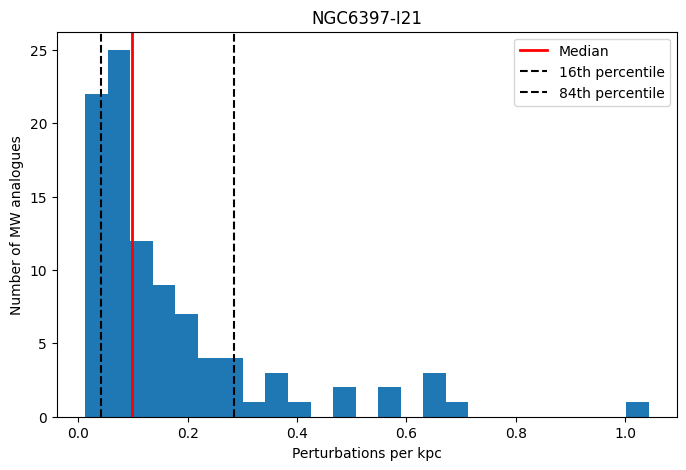


Jhelum-a-B19
Median      : 0.098
16th pctile : 0.042
84th pctile : 0.285


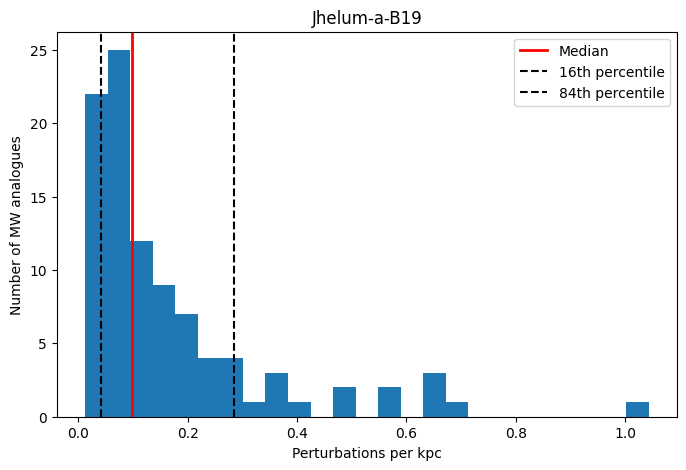

In [ ]:
R_INNER = 10.0      # kpc
R_OUTER = 40.0      # kpc

STREAM_AGE = 10.0   # Gyr
V_REL = 200.0       # km/s

BMAX_FACTOR = 5.0

KM_S_TO_KPC_GYR = 1.022712
v_rel = V_REL * KM_S_TO_KPC_GYR

V_shell = (4/3) * np.pi * (R_OUTER**3 - R_INNER**3)

print(f"Shell volume = {V_shell:.2e} kpc^3")





# Streams

stream_names = {
    15: "Indus-S19",
    20: "C-12-I24",
    41: "Ylgr-I21",
    48: "Orphan-K23",
    69: "NGC6397-I21",
    86: "Jhelum-a-B19"
}

# Looping over every stream

all_results = {}

for stream_id, stream_name in stream_names.items():

    print("\n===================================")
    print(stream_name)
    print("===================================")

    results = []



    # Looping over every MW analogue

    for halo_id, halo in all_halos.items():

        masses = halo["mass_msun"]
        radii = halo["R_kpc"]



        # Selecting subhalos inside shell

        inside_mask = (
            (radii >= R_INNER) &
            (radii <= R_OUTER)
        )

        masses = masses[inside_mask]

        if len(masses) == 0:
            continue

        rs = 1.05 * np.sqrt(masses / 1e8)

        bmax = BMAX_FACTOR * rs

        encounter_rate = np.sum(bmax * v_rel) / V_shell



        # Perturbations per kpc

        perturbations = encounter_rate * STREAM_AGE

        results.append({
            "stream": stream_name,
            "halo_id": halo_id,
            "N_subhalos": len(masses),
            "encounter_rate": encounter_rate,
            "perturbations_per_kpc": perturbations
        })



    results = pd.DataFrame(results)

    if len(results) == 0:
        print("No subhalos found.")
        continue

    all_results[stream_name] = results




    # -----------------------------------------------------------------------------
    # Statistical Analysis
    # -----------------------------------------------------------------------------

    # Taking the 16th and 84th percentile of the distribution, which is approximately equivalent to a 1σ interval for a Gaussian distribution, and covers around 68% of the distribution.
    # I did this because the lower bound was going into the negative, which I thought was not physically meaningful.


    median = results["perturbations_per_kpc"].median()

    lower = np.percentile(
        results["perturbations_per_kpc"],
        16
    )

    upper = np.percentile(
        results["perturbations_per_kpc"],
        84
    )

    print(f"Median      : {median:.3f}")
    print(f"16th pctile : {lower:.3f}")
    print(f"84th pctile : {upper:.3f}")

    # Plot

    plt.figure(figsize=(8,5))

    plt.hist(
        results["perturbations_per_kpc"],
        bins=25
    )

    plt.axvline(
        median,
        color="red",
        lw=2,
        label="Median"
    )

    plt.axvline(
        lower,
        color="black",
        ls="--",
        label="16th percentile"
    )

    plt.axvline(
        upper,
        color="black",
        ls="--",
        label="84th percentile"
    )

    plt.xlabel("Perturbations per kpc")
    plt.ylabel("Number of MW analogues")
    plt.title(stream_name)

    plt.legend()
    plt.show()